In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Fall 2025 Lab #3 Closing Prices.xlsx to Fall 2025 Lab #3 Closing Prices.xlsx


In [ ]:
filename = list(uploaded.keys())[0]
print("Uploaded file:", filename)

df = pd.read_excel(filename, parse_dates=["Date"])
df.head()

Uploaded file: Fall 2025 Lab #3 Closing Prices.xlsx


,Date,ACGL,AFL,AIG,AIZ,AJG,ALL,AMP,AON,APO,...,SYF,TFC,TROW,TRV,USB,V,WFC,WRB,WTW,XYZ
0,2024-11-01,91.305275,102.530380,74.113464,188.913422,278.153687,180.655151,499.303955,362.232605,139.193466,...,54.039066,40.812531,106.614655,241.643112,45.781742,288.141724,62.941711,56.354668,295.947693,72.150002
1,2024-11-04,90.335358,102.334549,74.710518,188.351898,279.393646,178.908951,500.182709,363.445282,137.643570,...,54.098019,40.097694,107.023773,238.859161,45.159710,289.241821,61.988049,56.384068,299.428253,72.690002
2,2024-11-05,91.761711,103.362694,73.790459,190.223679,280.871765,181.547897,507.449646,366.486908,147.357513,...,55.827263,40.335972,108.955124,240.856110,45.561642,290.668976,62.348106,57.050526,304.471191,72.379997
3,2024-11-06,96.706375,106.300247,75.385864,203.306549,288.351379,185.207108,560.253174,378.991364,161.573029,...,66.330490,44.796566,115.415176,249.817902,49.054600,304.652863,70.522346,59.461525,313.755951,77.639999
4,2024-11-07,94.899673,105.203560,74.964996,202.784424,288.232300,186.933701,540.683899,377.589844,157.772339,...,63.510632,44.034073,114.225914,248.175064,47.427750,303.067139,67.943573,58.432438,312.361755,75.269997


In [ ]:
# Cell 3 — Clean and prepare data

# Ensure Date is datetime and index it
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)
    df = df.set_index('Date')

print("Shape:", df.shape)
display(df.head())


Shape: (250, 74)


,ACGL,AFL,AIG,AIZ,AJG,ALL,AMP,AON,APO,AXP,...,SYF,TFC,TROW,TRV,USB,V,WFC,WRB,WTW,XYZ
Date,,,,,,,,,,,,,,,,,,,,,
2024-11-01,91.305275,102.530380,74.113464,188.913422,278.153687,180.655151,499.303955,362.232605,139.193466,269.783783,...,54.039066,40.812531,106.614655,241.643112,45.781742,288.141724,62.941711,56.354668,295.947693,72.150002
2024-11-04,90.335358,102.334549,74.710518,188.351898,279.393646,178.908951,500.182709,363.445282,137.643570,267.310425,...,54.098019,40.097694,107.023773,238.859161,45.159710,289.241821,61.988049,56.384068,299.428253,72.690002
2024-11-05,91.761711,103.362694,73.790459,190.223679,280.871765,181.547897,507.449646,366.486908,147.357513,272.999115,...,55.827263,40.335972,108.955124,240.856110,45.561642,290.668976,62.348106,57.050526,304.471191,72.379997
2024-11-06,96.706375,106.300247,75.385864,203.306549,288.351379,185.207108,560.253174,378.991364,161.573029,292.014313,...,66.330490,44.796566,115.415176,249.817902,49.054600,304.652863,70.522346,59.461525,313.755951,77.639999
2024-11-07,94.899673,105.203560,74.964996,202.784424,288.232300,186.933701,540.683899,377.589844,157.772339,283.763184,...,63.510632,44.034073,114.225914,248.175064,47.427750,303.067139,67.943573,58.432438,312.361755,75.269997


In [ ]:
# Cell 4 — Select your variables

selected = ["C","GS","JPM","BK","IBKR","MS","HOOD","COF","NDAQ","BAC","BEN","AXP",
            "GL","ERIE","MCO","HIG","TRV","WRB", "BLK"]

# Keep only columns that exist
selected = [col for col in selected if col in df.columns]

data = df[selected].copy()

print("Selected columns loaded:", data.columns.tolist())
print("Shape:", data.shape)
data.head()


Selected columns loaded: ['C', 'GS', 'JPM', 'BK', 'IBKR', 'MS', 'HOOD', 'COF', 'NDAQ', 'BAC', 'BEN', 'AXP', 'GL', 'ERIE', 'MCO', 'HIG', 'TRV', 'WRB', 'BLK']
Shape: (250, 19)


,C,GS,JPM,BK,IBKR,MS,HOOD,COF,NDAQ,BAC,BEN,AXP,GL,ERIE,MCO,HIG,TRV,WRB,BLK
Date,,,,,,,,,,,,,,,,,,,
2024-11-01,61.445297,508.964691,218.318436,73.678276,38.240170,113.667183,23.969999,161.926117,73.417305,40.799839,19.629189,269.783783,103.152916,408.951447,452.998230,108.279449,241.643112,56.354668,965.211487
2024-11-04,60.666893,501.242340,215.223938,73.375000,38.277466,112.976532,24.320000,159.337662,73.901360,40.379734,18.988695,267.310425,102.627335,396.461700,455.033142,109.331848,238.859161,56.384068,971.502014
2024-11-05,61.951256,516.422546,216.898468,74.363106,38.521168,114.601044,24.959999,164.050232,75.215210,40.917084,19.732796,272.999115,103.509918,402.558838,458.795197,109.794121,240.856110,57.050526,993.891052
2024-11-06,67.166565,584.062439,241.938416,76.505661,42.693817,127.908424,29.860001,188.670120,76.647591,44.365925,20.279099,292.014313,110.074730,421.588989,457.743042,114.800415,249.817902,59.461525,1009.048950
2024-11-07,66.271408,570.528564,231.479813,76.006714,41.445499,124.941505,29.360001,182.594177,77.230423,43.740639,20.053041,283.763184,107.694740,418.052856,462.140381,113.295570,248.175064,58.432438,1015.163269


In [ ]:
# Cell 5 — Missing values inspection

print("Missing values per column:")
print(data.isna().sum())

# If missing data exists, show example rows
if data.isna().any().any():
    display(data[data.isna().any(axis=1)].head())


Missing values per column:
C       0
GS      0
JPM     0
BK      0
IBKR    0
MS      0
HOOD    0
COF     0
NDAQ    0
BAC     0
BEN     0
AXP     0
GL      0
ERIE    0
MCO     0
HIG     0
TRV     0
WRB     0
dtype: int64


In [ ]:
# Cell 6 — Descriptive statistics for selected variables

desc = data.describe().T
desc['skew'] = data.skew()
desc['kurtosis'] = data.kurtosis()

print("Descriptive Statistics:")
display(desc)

Descriptive Statistics:


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
C,250.0,79.728156,12.467603,56.952473,69.152731,77.149578,92.778685,102.876602,0.336795,-1.215507
GS,250.0,639.336983,90.099021,457.478516,571.262177,614.293213,719.187607,806.320007,0.300520,-1.058533
JPM,250.0,265.268797,27.812136,208.259308,239.868546,262.402985,290.447906,314.530823,0.135238,-1.253456
BK,250.0,89.010309,11.252742,72.116707,79.375816,86.493813,100.872496,109.211365,0.417446,-1.209764
IBKR,250.0,53.353773,9.414219,35.971451,44.863009,51.791359,62.387898,72.620003,0.254784,-1.172303
MS,250.0,132.792696,15.131604,97.756958,123.314554,130.296288,142.054771,165.015411,0.189150,-0.539993
HOOD,250.0,72.804680,35.836759,23.969999,41.944999,56.850000,104.262497,152.460007,0.626339,-0.986109
COF,250.0,196.515605,19.012918,149.683548,182.014580,196.486069,214.349995,229.740005,-0.166984,-0.916991
NDAQ,250.0,83.084694,7.218962,66.007294,77.702126,81.321182,88.812315,96.667015,0.180885,-0.894308
BAC,250.0,45.308580,3.976890,33.999416,43.357644,45.367357,47.677310,53.450001,-0.276777,0.059819


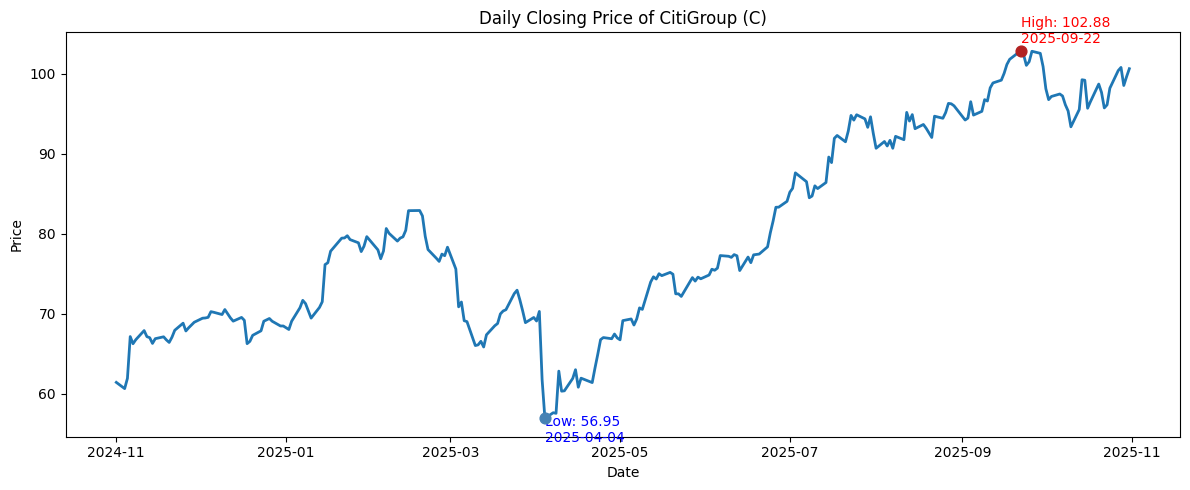

In [ ]:
# Cell 7 — Time series for Citi (C)

plt.figure(figsize=(12,5))
plt.plot(data.index, data['C'], linewidth=2, label="C")

# Identify high and low
max_idx = data['C'].idxmax()
min_idx = data['C'].idxmin()
max_val = data['C'].max()
min_val = data['C'].min()

# Plot the points
plt.scatter(max_idx, max_val, color='firebrick', s=60, zorder=5)
plt.scatter(min_idx, min_val, color='steelblue', s=60, zorder=5)

# Label the points (slightly offset so they don't sit directly on the marker)
plt.text(max_idx, max_val + 1,
         f"High: {max_val:.2f}\n{max_idx.date()}",
         color='red', fontsize=10)

plt.text(min_idx, min_val - 3,
         f"Low: {min_val:.2f}\n{min_idx.date()}",
         color='blue', fontsize=10)

plt.title("Daily Closing Price of CitiGroup (C)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.tight_layout()
plt.show()


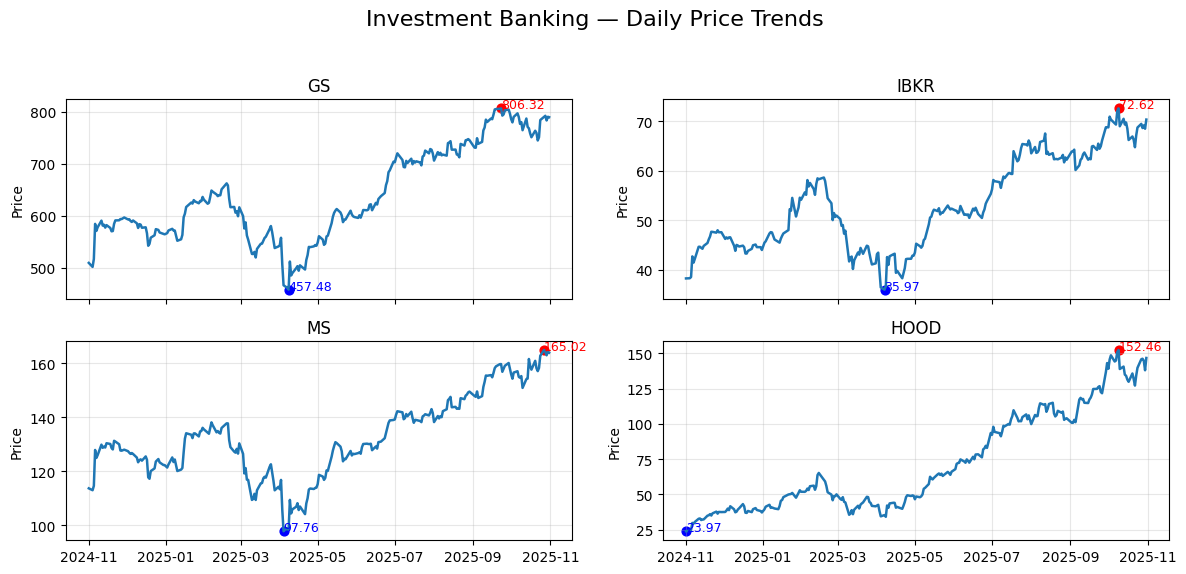

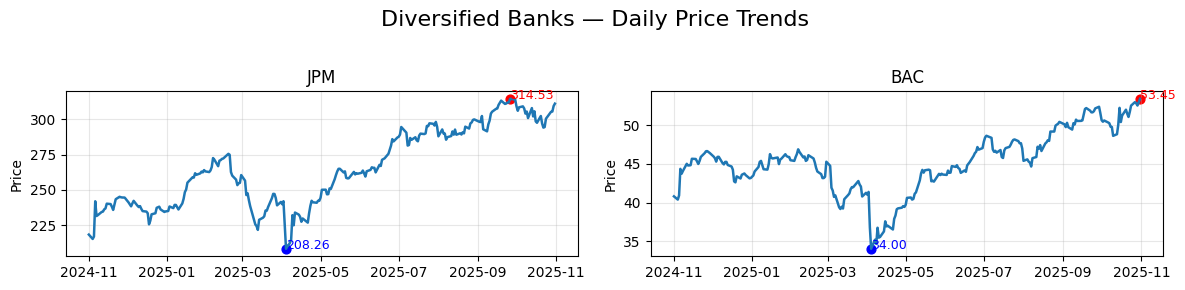

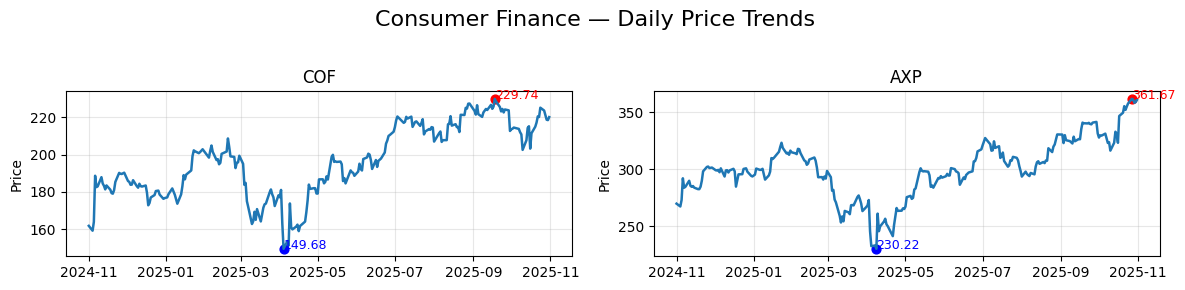

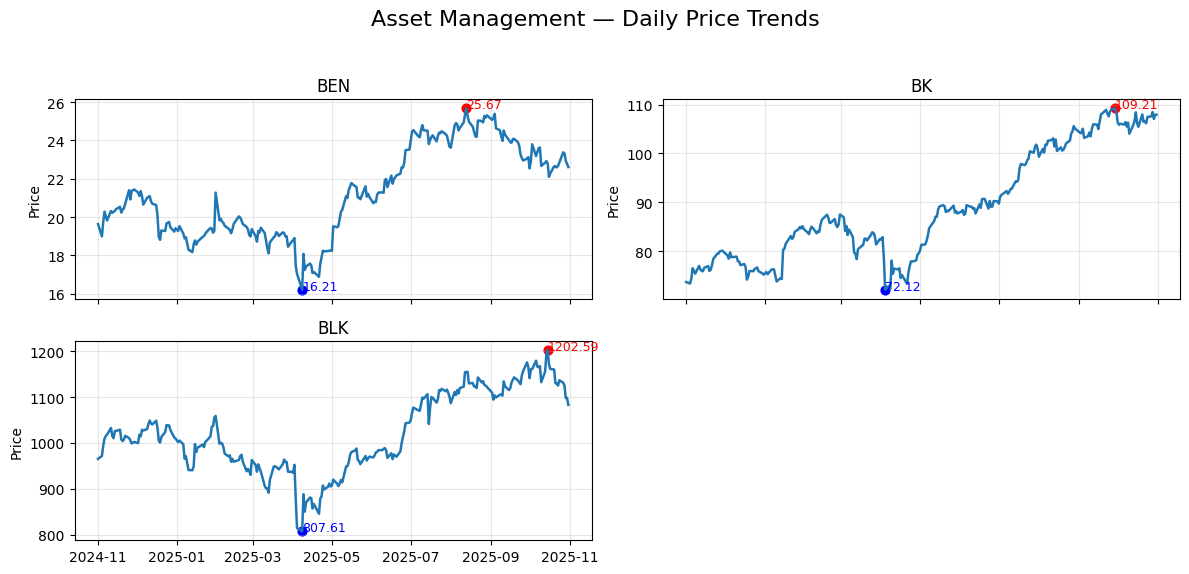

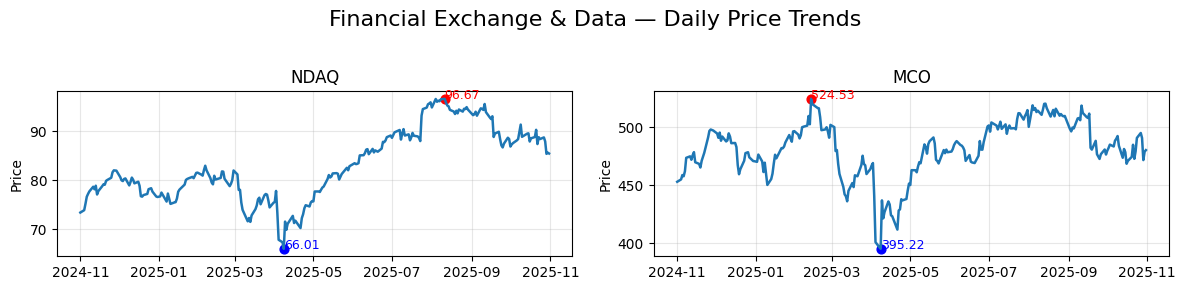

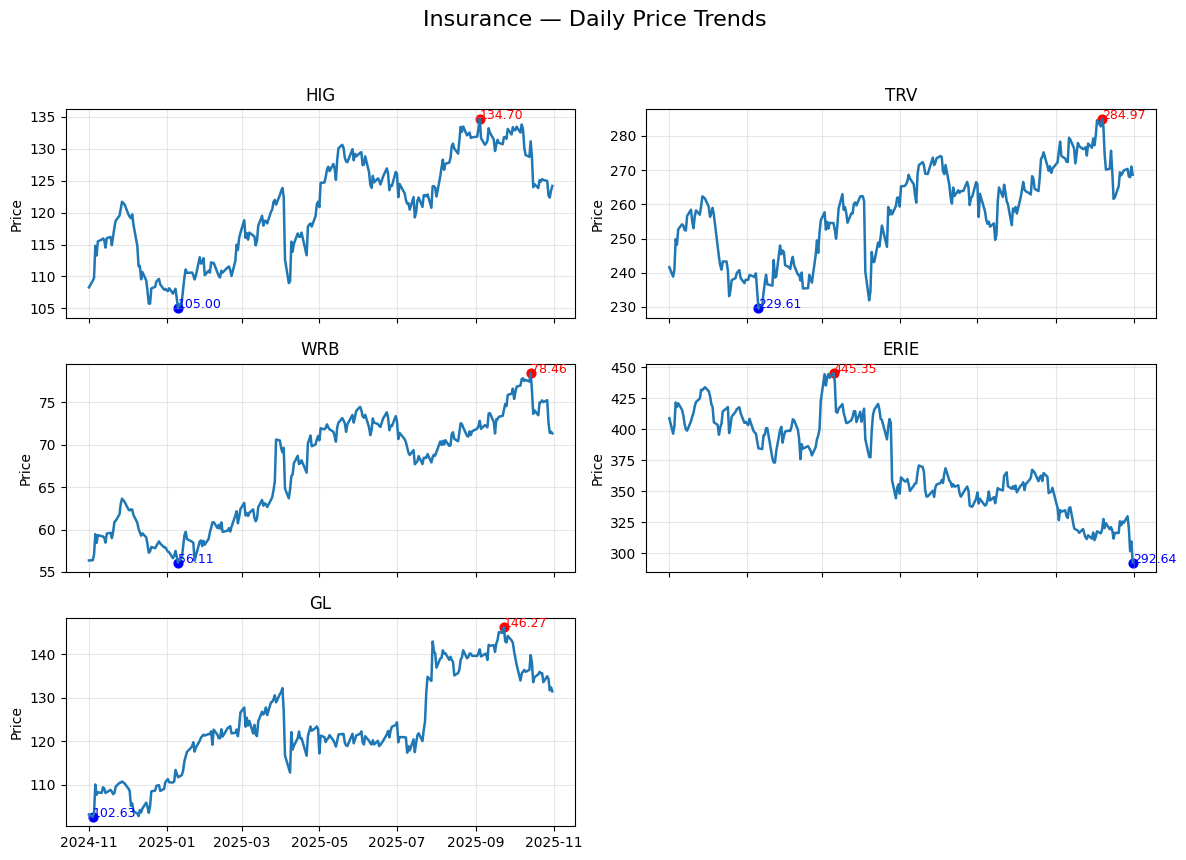

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt

# --- EDIT THIS MAPPING IF NEEDED ---
sectors = {
    "Investment Banking": ["GS", "IBKR", "MS", "HOOD"],
    "Diversified Banks": ["JPM", "BAC"],
    "Consumer Finance": ["COF", "AXP", "SYF"],
    "Asset Management": ["BEN", "BK", "BLK"],
    "Financial Exchange & Data": ["NDAQ", "MCO"],
    "Insurance": ["HIG", "TRV", "WRB", "ERIE", "GL"]
}

# keep only tickers that are actually in your dataset
for k, v in sectors.items():
    sectors[k] = [t for t in v if t in data.columns]

import os
os.makedirs("sector_plots", exist_ok=True)

for sector_name, tickers in sectors.items():
    n = len(tickers)
    if n == 0:
        continue

    cols = 2
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 3*rows), sharex=True)
    axes = np.array(axes).reshape(-1)  # flatten safely

    for i, ticker in enumerate(tickers):
        ax = axes[i]
        series = data[ticker].dropna()

        # raw price plot
        ax.plot(series.index, series.values, label=ticker, linewidth=1.8)
        ax.set_title(ticker)
        ax.set_ylabel("Price")
        ax.grid(alpha=0.3)

        # annotate high / low values
        max_idx = series.idxmax()
        min_idx = series.idxmin()
        max_val = series.max()
        min_val = series.min()

        ax.scatter(max_idx, max_val, color='red', s=40)
        ax.text(max_idx, max_val, f"{max_val:.2f}", color='red', fontsize=9)

        ax.scatter(min_idx, min_val, color='blue', s=40)
        ax.text(min_idx, min_val, f"{min_val:.2f}", color='blue', fontsize=9)

    # Turn off unused subplots
    for j in range(i+1, len(axes)):
        axes[j].axis("off")

    fig.suptitle(f"{sector_name} — Daily Price Trends", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(f"sector_plots/{sector_name.replace(' ', '_')}.png", dpi=150)
    plt.show()


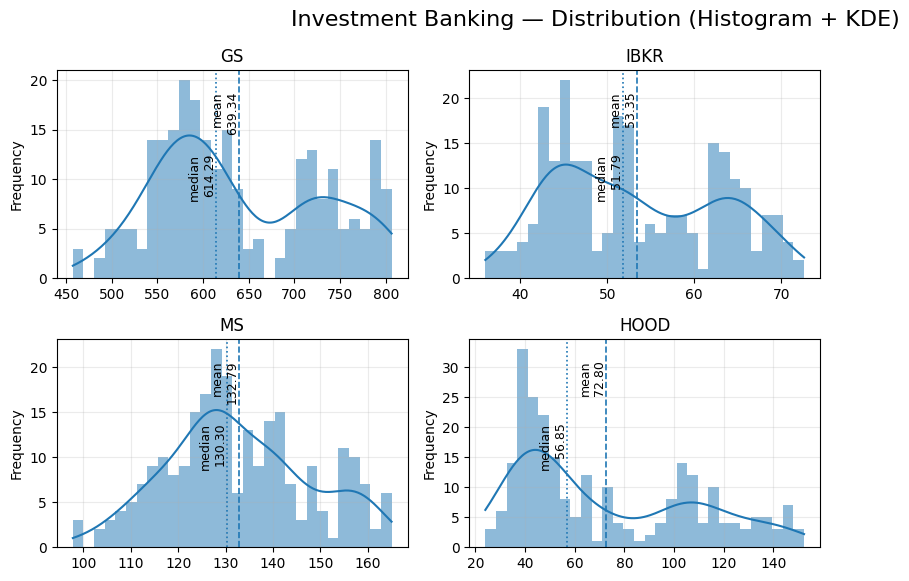

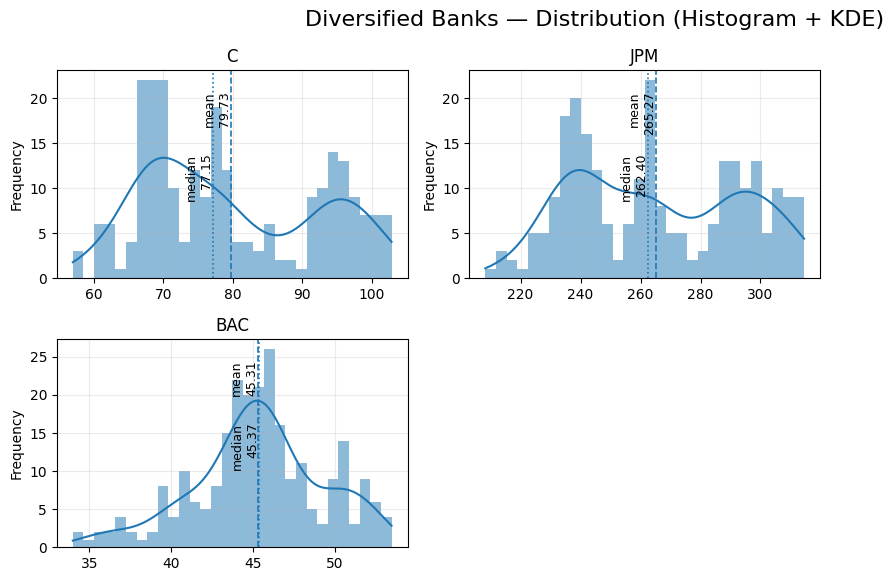

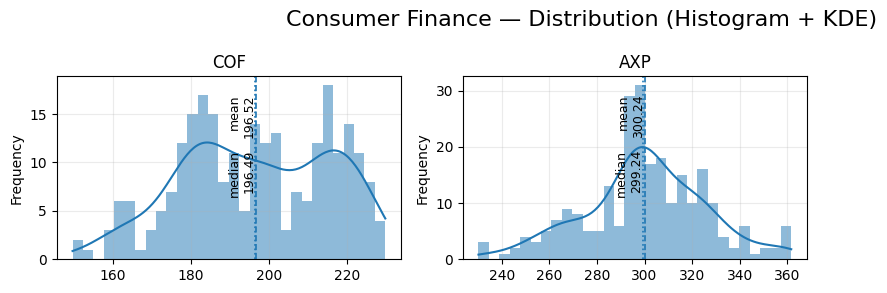

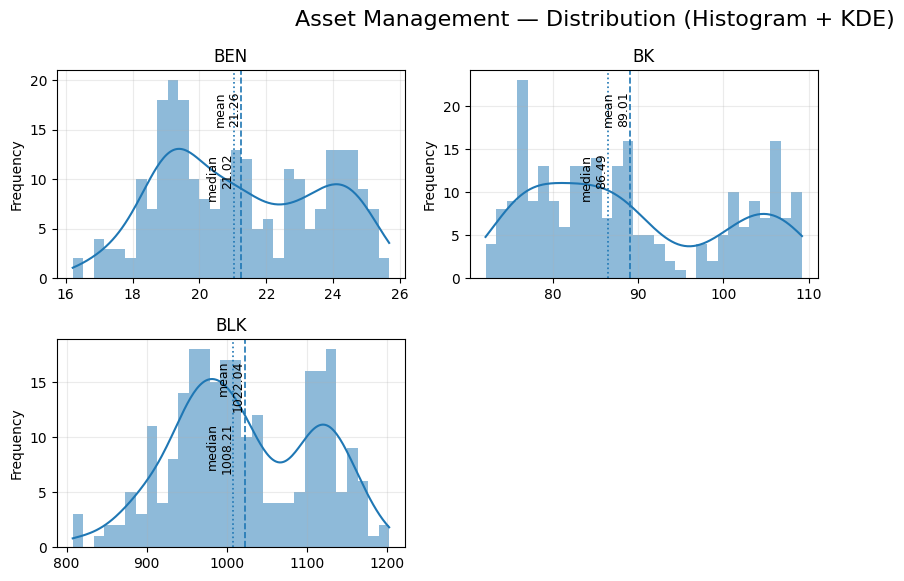

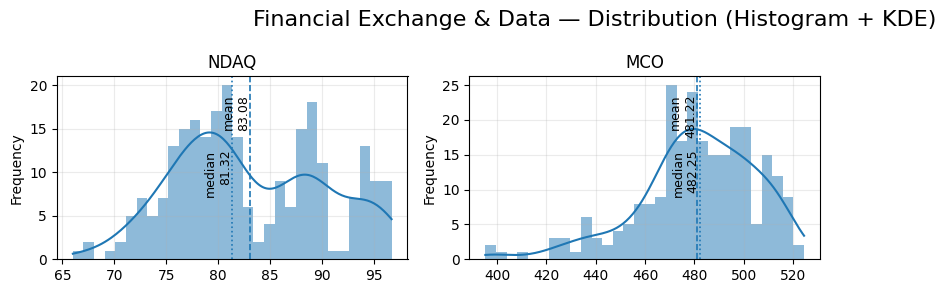

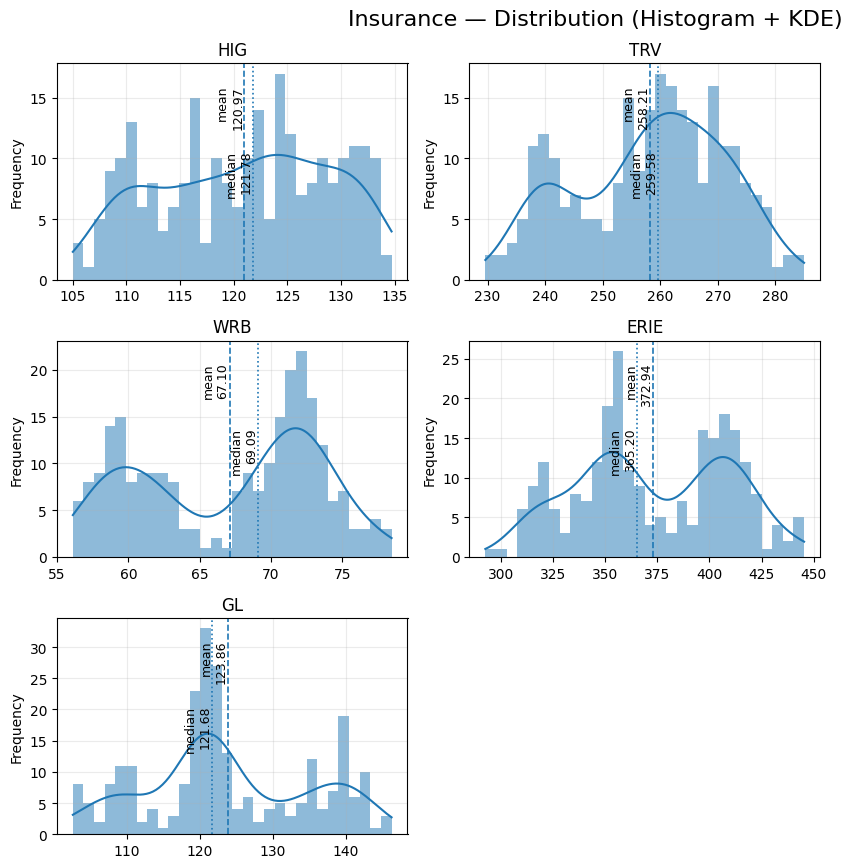

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- EDIT THIS MAPPING IF NEEDED ---
sectors = {
    "Investment Banking": ["GS", "IBKR", "MS", "HOOD"],
    "Diversified Banks": ["C", "JPM", "BAC"],
    "Consumer Finance": ["COF", "AXP", "SYF"],
    "Asset Management": ["BEN", "BK", "BLK"],
    "Financial Exchange & Data": ["NDAQ", "MCO"],
    "Insurance": ["HIG", "TRV", "WRB", "ERIE", "GL"]
}

# keep only tickers that are actually in your dataset
for k, v in sectors.items():
    sectors[k] = [t for t in v if t in data.columns]

os.makedirs("sector_plots", exist_ok=True)

for sector_name, tickers in sectors.items():
    n = len(tickers)
    if n == 0:
        continue

    cols = 2
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 3*rows), sharex=False)
    # Ensure axes is a flat numpy array no matter the shape
    axes = np.array(axes).reshape(-1)

    last_i = -1
    for i, ticker in enumerate(tickers):
        ax = axes[i]
        series = data[ticker].dropna()

        if series.empty:
            ax.set_title(ticker + " (no data)")
            ax.axis("off")
            last_i = i
            continue

        # histogram with KDE
        sns.histplot(series, bins=30, kde=True, ax=ax, stat="count", edgecolor=None)
        ax.set_title(ticker)
        ax.set_xlabel("")  # avoid clutter; set if desired
        ax.set_ylabel("Frequency")
        ax.grid(alpha=0.25)

        # annotate mean and median
        mean_val = series.mean()
        median_val = series.median()

        ax.axvline(mean_val, linestyle='--', linewidth=1.2)
        ax.text(mean_val, ax.get_ylim()[1]*0.9, f"mean\n{mean_val:.2f}", rotation=90, va='top', ha='right', fontsize=9)

        ax.axvline(median_val, linestyle=':', linewidth=1.2)
        ax.text(median_val, ax.get_ylim()[1]*0.6, f"median\n{median_val:.2f}", rotation=90, va='top', ha='right', fontsize=9)

        last_i = i

    # Turn off unused subplots
    for j in range(last_i+1, len(axes)):
        axes[j].axis("off")

    fig.suptitle(f"{sector_name} — Distribution (Histogram + KDE)", fontsize=16)
    plt.tight_layout(rect=[0, 0.02, 0.7, 1])
    plt.savefig(f"sector_plots/{sector_name.replace(' ', '_')}_histograms.png", dpi=150)
    plt.show()


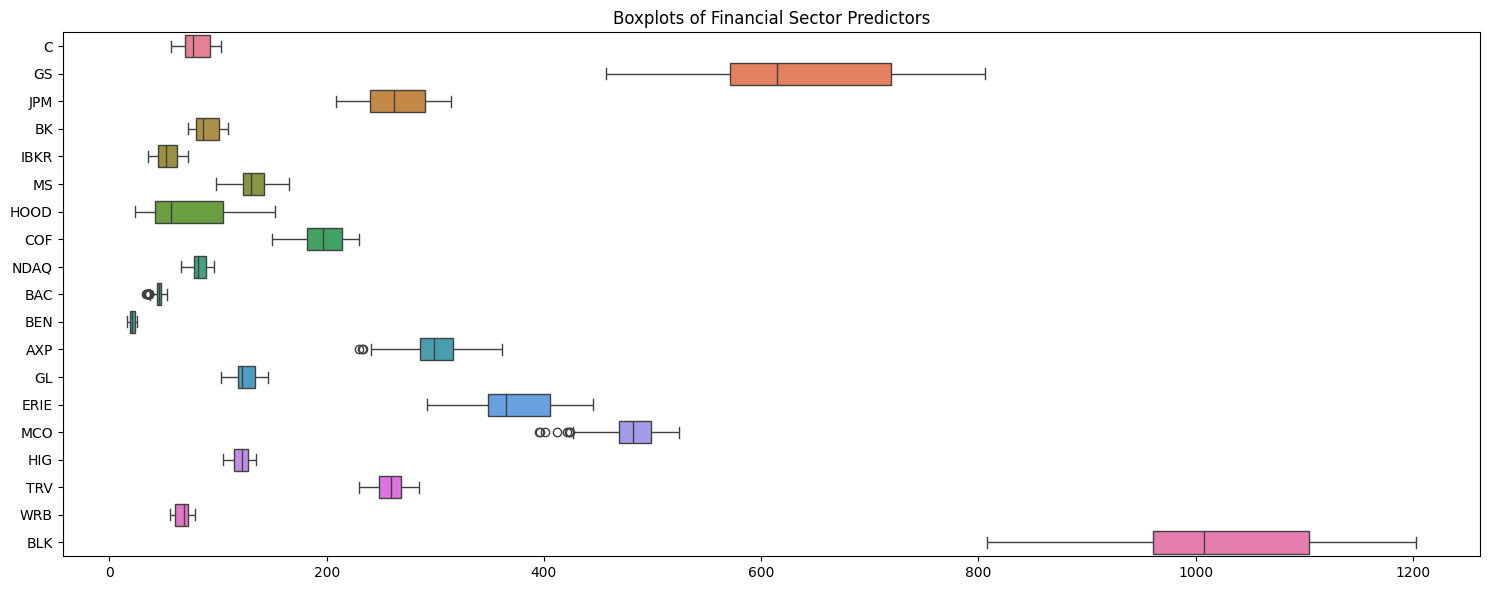

In [ ]:
# Cell 10 — Boxplots for outlier detection

plt.figure(figsize=(15,6))
sns.boxplot(data=data[selected], orient="h")
plt.title("Boxplots of Financial Sector Predictors")
plt.tight_layout()
plt.show()


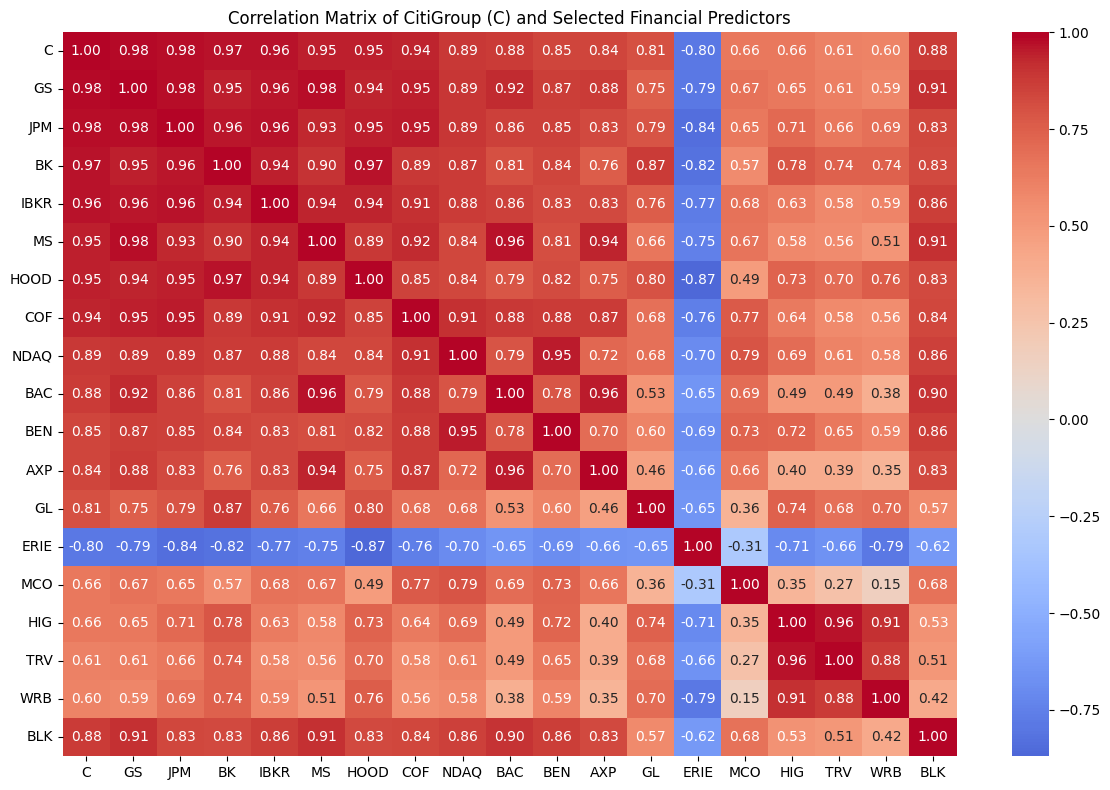

In [ ]:
# Cell 11 — Correlation heatmap

plt.figure(figsize=(12,8))
sns.heatmap(data.corr(), cmap="coolwarm", annot=True, fmt=".2f", center=0)
plt.title("Correlation Matrix of CitiGroup (C) and Selected Financial Predictors")
plt.tight_layout()
plt.show()


In [ ]:
# Cell 7 — Time series for Citi (C)

plt.figure(figsize=(12,5))
plt.plot(data.index, data['BLK'], linewidth=2, label="BLK")

# Identify high and low
max_idx = data['BLK'].idxmax()
min_idx = data['BLK'].idxmin()
max_val = data['BLK'].max()
min_val = data['BLK'].min()

# Plot the points
plt.scatter(max_idx, max_val, color='firebrick', s=60, zorder=5)
plt.scatter(min_idx, min_val, color='steelblue', s=60, zorder=5)

# Label the points (slightly offset so they don't sit directly on the marker)
plt.text(max_idx, max_val + 1,
         f"High: {max_val:.2f}\n{max_idx.date()}",
         color='red', fontsize=10)

plt.text(min_idx, min_val - 3,
         f"Low: {min_val:.2f}\n{min_idx.date()}",
         color='blue', fontsize=10)

plt.title("Daily Closing Price of BLK")
plt.xlabel("Date")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

KeyError: 'BLK'

<Figure size 1200x500 with 0 Axes>